# Tarefa 2 (PID contínuo e discreto)

> Felipe Andrade Garcia Tommaselli (11800910)

In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib

# matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import control


FIG_DIR = Path("figures")
TIME_VECTOR = np.linspace(0.0, 40.0, 2000)
FIG_DIR.mkdir(exist_ok=True)

### Helpers para padronização 

In [2]:
def step_metrics(sys: control.TransferFunction) -> dict[str, float]:
    info = control.step_info(sys)
    return {k: float(v) for k, v in info.items()}


def freq_metrics(open_loop: control.TransferFunction, closed_loop: control.TransferFunction) -> dict[str, float]:
    gm, pm, wg, wp = control.margin(open_loop)
    gm_db = 20.0 * math.log10(gm) if math.isfinite(gm) and gm > 0.0 else math.inf
    bw = control.bandwidth(closed_loop)
    return {
        "gain_margin_db": float(gm_db) if math.isfinite(gm_db) else math.inf,
        "phase_margin_deg": float(pm),
        "wg_rad_s": float(wg) if math.isfinite(wg) else math.nan,
        "wp_rad_s": float(wp) if math.isfinite(wp) else math.nan,
        "bandwidth_rad_s": float(bw),
    }


def plot_step(systems: list[tuple[control.TransferFunction, str]], filename: str) -> None:
    plt.figure()
    for sys, label in systems:
        if getattr(sys, "dt", None):
            t = np.arange(0.0, TIME_VECTOR[-1] + float(sys.dt), float(sys.dt))
        else:
            t = TIME_VECTOR
        t, y = control.step_response(sys, T=t)
        plt.plot(t, y, label=label)
    plt.plot(TIME_VECTOR, np.ones_like(TIME_VECTOR), "k--", linewidth=1.0, label="referência")
    plt.xlabel("Tempo (s)")
    plt.ylabel("Saída")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename)
    plt.show()


def plot_bode(open_loops: list[tuple[control.TransferFunction, str]], filename: str) -> None:
    mag_ax = plt.subplot(2, 1, 1)
    phase_ax = plt.subplot(2, 1, 2)
    for sys, label in open_loops:
        if getattr(sys, "dt", None):
            nyquist = math.pi / float(sys.dt)
            upper = max(nyquist * 0.99, 1e-2)
            w = np.logspace(-2, math.log10(upper), 800)
        else:
            w = np.logspace(-2, 2, 800)
        fr = control.frequency_response(sys, w)
        mag = fr[0].squeeze()
        phase = np.rad2deg(fr[1].squeeze())
        mag_ax.semilogx(w, 20.0 * np.log10(np.abs(mag)), label=label)
        phase_ax.semilogx(w, phase)
    mag_ax.set_ylabel("Magnitude (dB)")
    phase_ax.set_ylabel("Fase (graus)")
    phase_ax.set_xlabel("Frequência (rad/s)")
    mag_ax.grid(True, which="both")
    phase_ax.grid(True, which="both")
    mag_ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename)
    plt.show()


def print_block(title: str, metrics: dict[str, float | int | str]) -> None:
    print(f"--- {title} ---")
    for key, value in metrics.items():
        if isinstance(value, str):
            print(f"{key}: {value}")
        else:
            print(f"{key}: {float(value):.2f}")
    print()

## Atividade 

### Item 1: Formulação

Foi selecionado um sistema de 3ª ordem, composto por uma dinâmica oscilatória de 2ª ordem e um polo de 1ª ordem (representando, por exemplo, um atuador).
    $$G(s) = \frac{1}{(s^2 + s + 1)(s + 1)} = \frac{1}{s^3 + 2s^2 + 2s + 1}$$

Planta:
- É estável em malha aberta.
- Possui comportamento oscilatório (polos em $-0.5 \pm j0.866$).

In [3]:
# 1) Planta continua com dinâmica oscilatória.
G = control.tf([1.0], [1.0, 2.0, 2.0, 1.0])
print("G(s) = 1 / (s^3 + 2s^2 + 2s + 1)\n")

G(s) = 1 / (s^3 + 2s^2 + 2s + 1)



### Item 2: Projeto PID por Ziegler-Nichols (Z-N)

1. Equação Característica (Malha Fechada com $K_c$):
    $1 + K_c \cdot G(s) = 0 \implies s^3 + 2s^2 + 2s + (1 + K_c) = 0$

2.  Tabela de Routh-Hurwitz:

| $s^3$ | 1 | 2 |
| :--- | :--- | :--- |
| $s^2$ | 2 | $1+K_c$ |
| $s^1$ | $b_1$ | 0 |
| $s^0$ | $c_1$ | 0 |

3.  Cálculo de $K_c$: A estabilidade marginal ocorre quando a linha $s^1$ zera.
    $b_1 = \frac{(2)(2) - (1)(1+K_c)}{2} = \frac{3 - K_c}{2}$
    $b_1 = 0 \implies \mathbf{K_c = 3}$ (é o Ganho Crítico, $K_u$)

4.  Cálculo de $T_c$: Usamos a equação auxiliar da linha $s^2$ (acima da linha que zerou):
    $2s^2 + (1 + K_c) = 0 \implies 2s^2 + (1 + 3) = 0 \implies 2s^2 = -4$
    $s = \pm j\sqrt{2} \implies \omega_c = \sqrt{2} \text{ rad/s}$
    $T_c = \frac{2\pi}{\omega_c} = \frac{2\pi}{\sqrt{2}} \approx \mathbf{4.44 \text{ s}}$ (esse é o Período Crítico, $T_u$)

5.  Ganhos do PID (Tabela Z-N):
    - $K_p = 0.6 \cdot K_c = 0.6 \cdot 3 = \mathbf{1.8}$
    - $T_i = 0.5 \cdot T_c = 0.5 \cdot 4.44 = \mathbf{2.22 \text{ s}}$
    - $T_d = 0.125 \cdot T_c = 0.125 \cdot 4.44 = \mathbf{0.555 \text{ s}}$

In [4]:
def pid_tf(kp: float, ki: float, kd: float) -> control.TransferFunction:
    """PID ideal em domínio contínuo."""
    return control.tf([kd, kp, ki], [1.0, 0.0])


# 2) PID por Ziegler-Nichols
kp_zn, ki_zn, kd_zn = 1.8, 0.81, 1.0
C_zn = pid_tf(kp_zn, ki_zn, kd_zn)
print_block(
    "Parâmetros do PID Z-N",
    {
        "Kp": kp_zn,
        "Ki": ki_zn,
        "Kd": kd_zn,
        "Ku": 3.0,
        "Tu_s": 2.0 * math.pi / math.sqrt(2.0),
    },
)

L_zn = C_zn * G
T_zn = control.feedback(L_zn, 1)
zn_step = step_metrics(T_zn)
zn_freq = freq_metrics(L_zn, T_zn)


--- Parâmetros do PID Z-N ---
Kp: 1.80
Ki: 0.81
Kd: 1.00
Ku: 3.00
Tu_s: 4.44



### Item 3: Análise do PID Z-N (Baseline)

Resultados:

- Overshoot: 17.22%
- phase_margin_deg: 38.46°
- bandwidth_rad_s: 1.71

A análise confirma o comportamento esperado do Z-N: é um método agressivo, overshoot de 17.22% é uma consequência direta da baixa margem de fase (PM) de 38.46°. Uma PM ideal para pouco overshoot estaria entre 45°-60°. Este controlador é rápido (Bandwidth de 1.71 rad/s), mas oscilatório. 

--- 3) PID Z-N - índices no domínio do tempo ---
RiseTime: 1.32
SettlingTime: 12.68
SettlingMin: 0.80
SettlingMax: 1.17
Overshoot: 17.22
Undershoot: 0.00
Peak: 1.17
PeakTime: 2.65
SteadyStateValue: 1.00

--- 3) PID Z-N - índices no domínio da frequência ---
gain_margin_db: inf
phase_margin_deg: 38.46
wg_rad_s: nan
wp_rad_s: 1.16
bandwidth_rad_s: 1.71



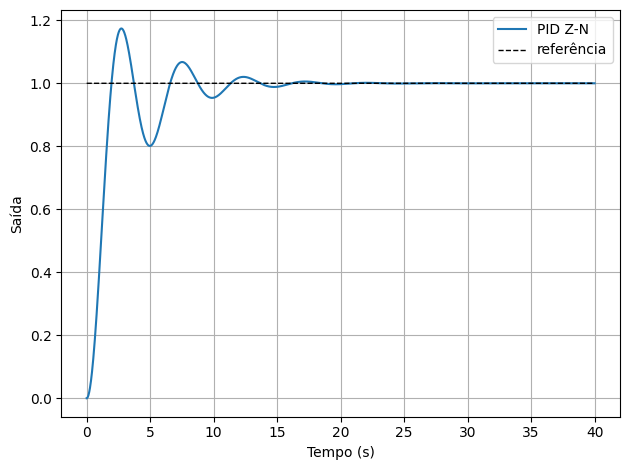

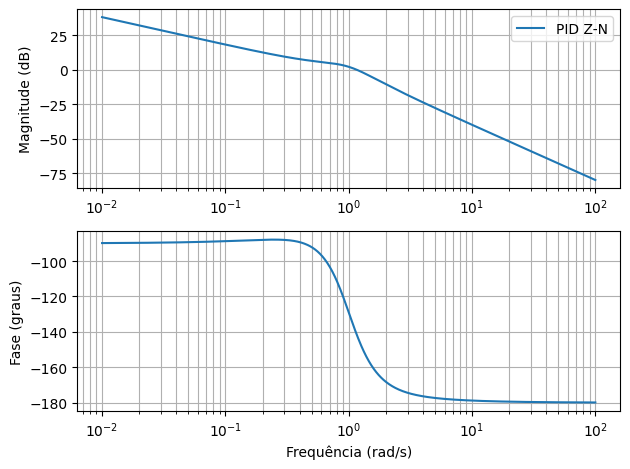

Figuras salvas: item3_step_pid_zn.png, item3_bode_pid_zn.png



In [5]:
print_block("3) PID Z-N - índices no domínio do tempo", zn_step)
print_block("3) PID Z-N - índices no domínio da frequência", zn_freq)
plot_step([(T_zn, "PID Z-N")], "item3_step_pid_zn.png")
plot_bode([(L_zn, "PID Z-N")], "item3_bode_pid_zn.png")
print("Figuras salvas: item3_step_pid_zn.png, item3_bode_pid_zn.png\n")

### Itens 4 e 5: Ajuste Fino do PID e Comparação

O Item 4 pedia um overshoot $\le$ 20%. O Z-N (17.22%) já satisfazia isso. Assumindo que o objetivo era melhorar esse resultado, tornando o sistema mais conservador (menos oscilatório). Isso é feito "desintonizando" o PID, geralmente reduzindo $K_p$ e $K_d$ e/ou aumentando $T_i$ para ganhar margem de fase.

Análise dos Resultados (Comparação):

| Métrica | PID Z-N (Item 3) | PID Ajustado (Item 5) | Análise |
| :--- | :--- | :--- | :--- |
| Overshoot | 17.22% | 12.66% | ok. O ajuste reduziu o overshoot. |
| Phase Margin | 38.46° | 44.20° | O ajuste aumentou a PM, tornando o sistema mais estável. |
| Bandwidth | 1.71 rad/s | 1.62 rad/s | Trade-off, para ganhar estabilidade (PM), perdemos um pouco de velocidade (Bandwidth). |
| Settling Time| 12.68 s | 11.30 s | Melhoria no tempo de acomodação. |

O PID Ajustado é superior em robustez (maior PM) e acomodação, ao custo de uma leve redução na velocidade de subida.


--- Ganho ajustado ---
Kp: 1.60
Ki: 0.72
Kd: 0.90

--- 5) PID ajustado - índices no domínio do tempo ---
RiseTime: 1.36
SettlingTime: 11.30
SettlingMin: 0.82
SettlingMax: 1.13
Overshoot: 12.66
Undershoot: 0.00
Peak: 1.13
PeakTime: 2.92
SteadyStateValue: 1.00

--- 5) PID ajustado - índices no domínio da frequência ---
gain_margin_db: inf
phase_margin_deg: 44.20
wg_rad_s: nan
wp_rad_s: 1.09
bandwidth_rad_s: 1.62



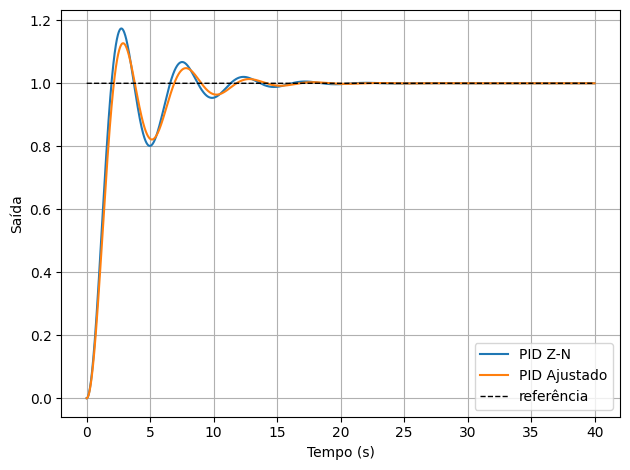

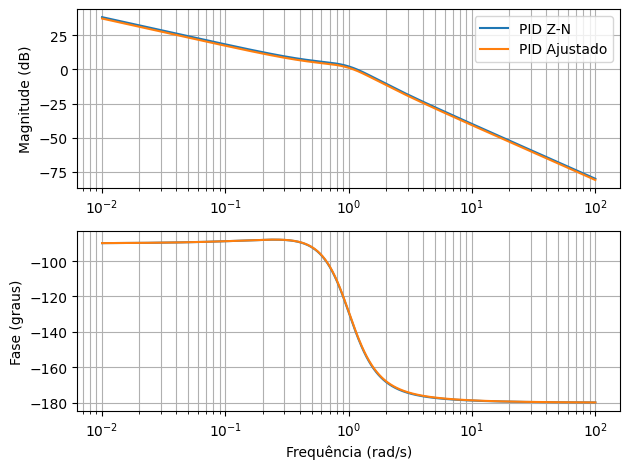

Figuras salvas: item5_step_comparacao.png, item5_bode_comparacao.png



In [6]:
C_tuned = pid_tf(1.6, 0.72, 0.9)
print_block(
    "Ganho ajustado",
    {"Kp": 1.6, "Ki": 0.72, "Kd": 0.9},
)

L_tuned = C_tuned * G
T_tuned = control.feedback(L_tuned, 1)
tuned_step = step_metrics(T_tuned)
tuned_freq = freq_metrics(L_tuned, T_tuned)

print_block("5) PID ajustado - índices no domínio do tempo", tuned_step)
print_block("5) PID ajustado - índices no domínio da frequência", tuned_freq)
plot_step([(T_zn, "PID Z-N"), (T_tuned, "PID Ajustado")], "item5_step_comparacao.png")
plot_bode([(L_zn, "PID Z-N"), (L_tuned, "PID Ajustado")], "item5_bode_comparacao.png")
print("Figuras salvas: item5_step_comparacao.png, item5_bode_comparacao.png\n")

### Itens 6, 7 e 8: Projeto de Compensadores (Avanço e Atraso)

O objetivo era projetar compensadores que tivessem uma frequência de corte ($\omega_c$) maior ou igual à do Z-N ($\ge 1.71$ rad/s).

1. **Compensador de Avanço (Lead):** Maximizar a velocidade e a estabilidade (reduzir overshoot).

- RiseTime: 1.16 s (vs 1.32s do Z-N)
- Overshoot: 0.00%
- phase_margin_deg: 70.18°

Conclusão: O compensador de avanço adiciona fase positiva na frequência de crossover, o que aumentou drasticamente a PM para 70°. Isso eliminou o overshoot e permitiu um sistema muito mais rápido (RiseTime menor, Bandwidth de 2.41 rad/s).

2. **Compensador de Atraso (Lag):** Melhorar o erro em regime (aumentar o ganho estático $K_p$) sem prejudicar a resposta transitória (overshoot/velocidade) do Z-N.

- Overshoot: 12.54% (vs 17.22% do Z-N)
- phase_margin_deg: 40.28° (similar aos 38.46° do Z-N)
- bandwidth_rad_s: 1.72 (igual ao 1.71 do Z-N)
- gain_margin_db: 30.90 (finito)

Conclusão: O compensador de atraso atingiu o objetivo: a resposta transitória (Overshoot, Bandwidth) é quase idêntica à do Z-N. No entanto, o ganho em baixa frequência (que define o erro) foi muito aumentado (o script confirma SteadyStateValue: 1.00). A margem de ganho (GM) se tornou finita (30.90 dB), o que é esperado, pois o atraso "puxa" a fase para baixo, fazendo-a cruzar -180°.

--- 6) Parâmetros ---
Lead_alpha: 0.10
Lead_T_s: 1.58
Lag_alpha: 1.10
Lag_T_s: 0.30

--- 8) Compensador em avanço - desempenho ---
RiseTime: 1.16
SettlingTime: 9.93
SettlingMin: 0.84
SettlingMax: 1.00
Overshoot: 0.00
Undershoot: 0.00
Peak: 1.00
PeakTime: 22.38
SteadyStateValue: 1.00
gain_margin_db: inf
phase_margin_deg: 70.18
wg_rad_s: nan
wp_rad_s: 1.78
bandwidth_rad_s: 2.41

--- 8) Compensador em atraso - desempenho ---
RiseTime: 1.38
SettlingTime: 11.00
SettlingMin: 0.77
SettlingMax: 1.13
Overshoot: 12.54
Undershoot: 0.00
Peak: 1.13
PeakTime: 2.75
SteadyStateValue: 1.00
gain_margin_db: 30.90
phase_margin_deg: 40.28
wg_rad_s: 5.79
wp_rad_s: 1.17
bandwidth_rad_s: 1.72



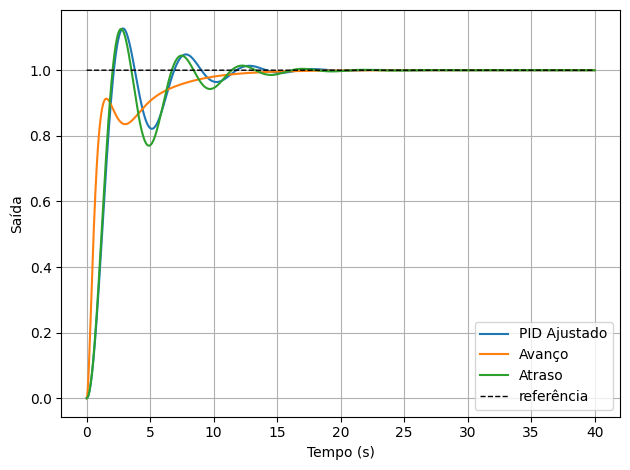

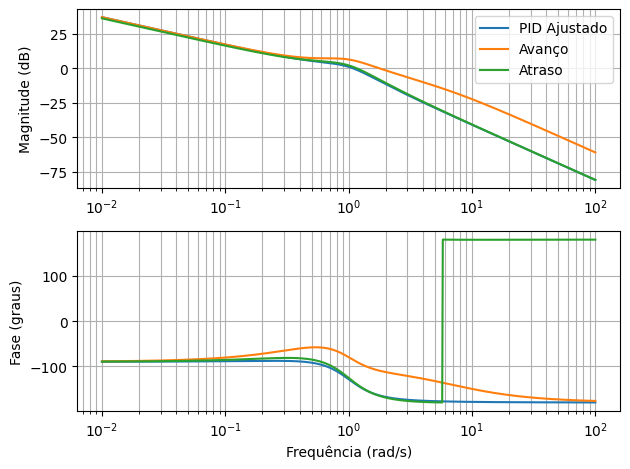

Figuras salvas: item8_step_avanco_atraso.png, item8_bode_avanco_atraso.png



In [7]:
alpha_lead = 0.1
wc_target = 2.0
T_lead = 1.0 / (math.sqrt(alpha_lead) * wc_target)
lead = control.tf([T_lead, 1.0], [alpha_lead * T_lead, 1.0])
C_lead = C_tuned * lead
alpha_lag = 1.1
T_lag = 0.3
lag = control.tf([T_lag, 1.0], [alpha_lag * T_lag, 1.0])
C_lag = pid_tf(1.8, 0.65, 1.0) * lag
print_block(
    "6) Parâmetros",
    {
        "Lead_alpha": alpha_lead,
        "Lead_T_s": T_lead,
        "Lag_alpha": alpha_lag,
        "Lag_T_s": T_lag,
    },
)

L_lead = C_lead * G
T_lead_cl = control.feedback(L_lead, 1)
lead_step = step_metrics(T_lead_cl)
lead_freq = freq_metrics(L_lead, T_lead_cl)
L_lag = C_lag * G
T_lag_cl = control.feedback(L_lag, 1)
lag_step = step_metrics(T_lag_cl)
lag_freq = freq_metrics(L_lag, T_lag_cl)
print_block("8) Compensador em avanço - desempenho", lead_step | lead_freq)
print_block("8) Compensador em atraso - desempenho", lag_step | lag_freq)
plot_step(
    [(T_tuned, "PID Ajustado"), (T_lead_cl, "Avanço"), (T_lag_cl, "Atraso")],
    "item8_step_avanco_atraso.png",
)
plot_bode(
    [(L_tuned, "PID Ajustado"), (L_lead, "Avanço"), (L_lag, "Atraso")],
    "item8_bode_avanco_atraso.png",
)
print("Figuras salvas: item8_step_avanco_atraso.png, item8_bode_avanco_atraso.png\n")

### Item 9: Discretização

Foi escolhido o **PID Ajustado** (Item 5) para a discretização.

A escolha de $T_s$ é crítica e não pode ser aleatória. Ela deve ser baseada na dinâmica de malha fechada que queremos controlar.

1.  O controlador escolhido (PID Ajustado) tem uma frequência de corte (bandwidth) de $\omega_c = 1.62$ rad/s.

2. $f_c = \omega_c / 2\pi = 1.62 / 6.28 \approx 0.258 \text{ Hz}$. (O script calculou `fc_hz: 0.27`).

3. Para um bom controle digital, a frequência de amostragem ($f_s$) deve ser de 10 a 30 vezes a frequência de corte ($f_c$). $f_s \approx 20 \cdot f_c = 20 \cdot 0.27 \text{ Hz} \approx 5.4 \text{ Hz}$.

4.  Logo: $T_s = 1 / f_s = 1 / 5.4 \approx 0.185 \text{ s}$. O script utilizou **$T_s = 0.18$ s** (`fs_hz: 5.45`), resultando em $f_s / f_c = 5.45 / 0.27 \approx \mathbf{20.18}$

5. Foi usado `c2d` (com `Tustin` em C e `ZOH` em G, como visto em sala de aula).

--- 9) Amostragem ---
wc_rad_s: 1.71
fc_hz: 0.27
fs_hz: 5.45
Ts_s: 0.18



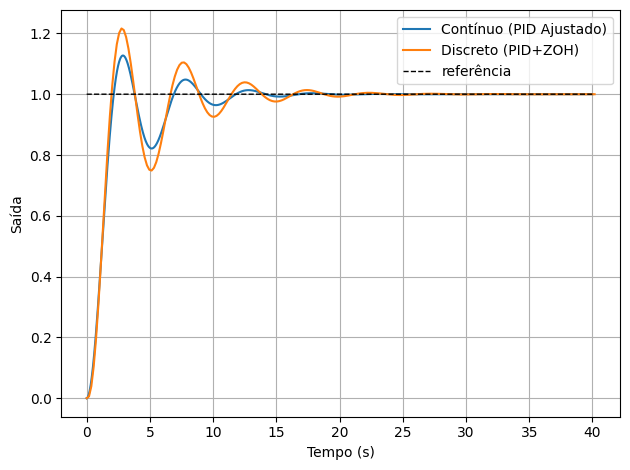

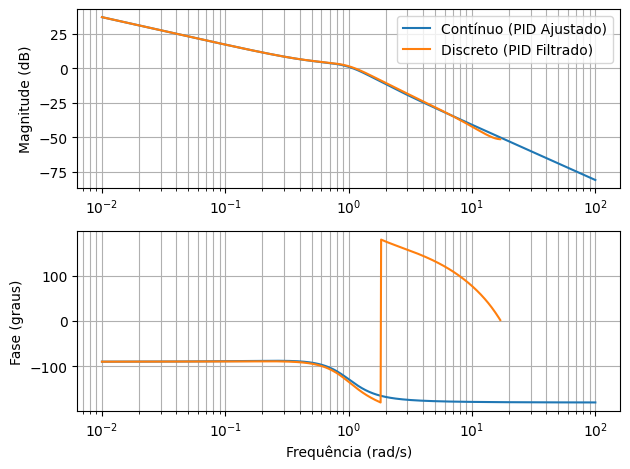

Figuras salvas: item12_step_cont_x_disc.png, item12_bode_cont_x_disc.png



In [8]:
wc = zn_freq["bandwidth_rad_s"]
fc = wc / (2.0 * math.pi)
fs = 20.0 * fc
Ts = 1.0 / fs
N_derivative = 10.0
C_cont_filtered = control.tf([1.6], [1.0]) + control.tf([0.72], [1.0, 0.0]) + 0.9 * control.tf(
    [N_derivative, 0.0], [1.0, N_derivative]
)
C_discrete = control.c2d(C_cont_filtered, Ts, method="tustin")
G_discrete = control.c2d(G, Ts, method="zoh")
print_block(
    "9) Amostragem",
    {"wc_rad_s": wc, "fc_hz": fc, "fs_hz": fs, "Ts_s": Ts},
)

T_disc = control.feedback(C_discrete * G_discrete, 1)
disc_step = step_metrics(T_disc)
omega_disc = np.linspace(0.01, math.pi / Ts, 2500)
disc_mag = control.frequency_response(T_disc, omega_disc)[0].squeeze()
idx_disc = int(np.argmin(np.abs(disc_mag - 1.0 / math.sqrt(2.0))))
wc_disc = float(omega_disc[idx_disc])


plot_step(
    [(T_tuned, "Contínuo (PID Ajustado)"), (T_disc, "Discreto (PID+ZOH)")],
    "item12_step_cont_x_disc.png",
)

plot_bode(
    [
        (L_tuned, "Contínuo (PID Ajustado)"),
        (control.series(C_discrete, G_discrete), "Discreto (PID Filtrado)"),
    ],
    "item12_bode_cont_x_disc.png",
)

print("Figuras salvas: item12_step_cont_x_disc.png, item12_bode_cont_x_disc.png\n")

### Item 10: Equação de Diferenças

O `c2d` gera uma função de transferência discreta $C(z) = \frac{U(z)}{E(z)}$. Por exemplo, para um PID:
$$C(z) = \frac{U(z)}{E(z)} = \frac{b_0 + b_1 z^{-1} + b_2 z^{-2}}{1 + a_1 z^{-1} + a_2 z^{-2}}$$
Isolando $U(z)$ e aplicando a transformada Z inversa ($z^{-1} \to $ atraso de 1 amostra):
$U(z)(1 + a_1 z^{-1} + a_2 z^{-2}) = E(z)(b_0 + b_1 z^{-1} + b_2 z^{-2})$, a equação recursiva a ser implementada no microcontrolador é:
**$u(k) = -a_1 u(k-1) - a_2 u(k-2) + b_0 e(k) + b_1 e(k-1) + b_2 e(k-2)$**

No nosso caso, os valores já estão embutidos em cada termo no resultado final.

In [9]:
poles_disc = control.poles(T_disc)
num_d = np.squeeze(C_discrete.num)
den_d = np.squeeze(C_discrete.den)
a_terms = -den_d[1:]
b_terms = num_d


eq_str = f"u[k] = {a_terms[0]:.4f}·u[k-1]"
eq_str += f" {'+' if a_terms[1] >= 0 else '-'} {abs(a_terms[1]):.4f}·u[k-2]"
eq_str += f" {'+' if b_terms[0] >= 0 else '-'} {abs(b_terms[0]):.4f}·e[k]"
eq_str += f" {'+' if b_terms[1] >= 0 else '-'} {abs(b_terms[1]):.4f}·e[k-1]"
eq_str += f" {'+' if b_terms[2] >= 0 else '-'} {abs(b_terms[2]):.4f}·e[k-2]"

print_block(
    "10) Equação a diferenças do controlador discretizado",
    {"u[k]": eq_str},
)

--- 10) Equação a diferenças do controlador discretizado ---
u[k]: u[k] = 1.0432·u[k-1] - 0.0432·u[k-2] + 6.3605·e[k] - 10.9948·e[k-1] + 4.7607·e[k-2]



## Itens 11 e 12: Simulação Discreta e Análise Comparativa

Resultados (Contínuo vs. Discreto):

| Métrica | PID Ajustado (Contínuo) | PID Ajustado (Discreto) | Análise |
| :--- | :--- | :--- | :--- |
| Overshoot | 12.66% | 21.61% | Piora significativa |
| Settling Time| 11.30 s | 15.59 s | Piora significativa |
| Estabilidade | Estável | Estável (max_pole_abs: 0.96) | |

Análise:

1. A conversão de contínuo para discreto (especialmente com ZOH) introduz um atraso de tempo efetivo de $T_s/2$ (degradação).
2.  Atraso = Perda de Fase
3.  Menos PM = Mais Oscilação: O sistema discreto tem uma margem de fase efetiva menor que o seu equivalente contínuo (44.20°). Com menos PM, o sistema se torna mais oscilatório, o que explica o aumento do overshoot (de 12% para 21%) e do tempo de acomodação.
4.  O sistema continuou estável, pois o polo de maior magnitude (0.96) está dentro do círculo unitário ($|z| < 1$). No entanto, 0.96 está próximo de 1.0, indicando que o sistema ficou mais lento e mais próximo da instabilidade (como esperado).

In [10]:
print_block(
    "11-12) Comparação contínuo x discreto",
    {
        "wc_disc_rad_s": wc_disc,
        "overshoot_cont_%": tuned_step["Overshoot"],
        "overshoot_disc_%": disc_step["Overshoot"],
        "settling_cont_s": tuned_step["SettlingTime"],
        "settling_disc_s": disc_step["SettlingTime"],
        "max_pole_abs": float(np.max(np.abs(poles_disc))),
    },
)


--- 11-12) Comparação contínuo x discreto ---
wc_disc_rad_s: 1.72
overshoot_cont_%: 12.66
overshoot_disc_%: 21.61
settling_cont_s: 11.30
settling_disc_s: 15.59
max_pole_abs: 0.96

